## K-Fold Cross-Validation Summary

Groups all `fold{i}of{k}` directories by their base variant name, extracts the
**best-iteration** metrics per fold (highest `segm/AP`), then plots mean ± 1 std across folds.

In [9]:
# Self-contained setup for the K-Fold section
# (these imports/helpers are also defined earlier in the notebook;
# duplicating here lets you run the section standalone)
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("output")


# Which eval dataset to summarise across folds.
# Fold-specific held-out validation is the right default for k-fold CV.
# Switch to "rob2pheno_val" to use the full validation set instead.
EVAL_DATASET = "rob2pheno_fold_val"


def load_metrics(
    run_dir: Path,
    eval_dataset: str = EVAL_DATASET,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read metrics.json (JSONL) and split into (train_df, eval_df).

    Detectron2 prefixes eval keys with the registered dataset name when
    more than one eval dataset is present, e.g. "rob2pheno_fold_val/segm/AP".
    This loader strips that prefix so downstream code can use the short
    names ("segm/AP", "segm/AP50", ...).
    """
    records = []
    with (run_dir / "metrics.json").open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    train_rows = [r for r in records if "total_loss" in r]
    eval_rows  = [
        r for r in records
        if any(k == "segm/AP" or k.endswith("/segm/AP") for k in r)
    ]

    def _to_df(rows):
        df = pd.DataFrame(rows)
        if df.empty or "iteration" not in df.columns:
            return df
        return df.sort_values("iteration").reset_index(drop=True)

    train_df = _to_df(train_rows)
    eval_df  = _to_df(eval_rows)

    if not eval_df.empty:
        prefix = f"{eval_dataset}/"
        rename = {c: c[len(prefix):] for c in eval_df.columns if c.startswith(prefix)}
        if rename:
            keep_cols = ["iteration"] + list(rename.keys())
            keep_cols = [c for c in keep_cols if c in eval_df.columns]
            eval_df = eval_df[keep_cols].rename(columns=rename)
        # else: columns already use the short form (older runs) - leave as-is

    return train_df, eval_df


def fold_variant_key(dirname: str) -> str:
    """Strip _fold{i}of{k}_seed{s} to get the base variant name."""
    return re.sub(r"_fold\d+of\d+_seed\d+", "", dirname)


# Auto-discover all fold directories in output/
fold_groups: dict[str, list[str]] = {}
for d in sorted(OUTPUT_DIR.iterdir()):
    if d.is_dir() and re.search(r"_fold\d+of\d+", d.name):
        key = fold_variant_key(d.name)
        fold_groups.setdefault(key, []).append(d.name)

print("Discovered fold groups:")
for key, folds in fold_groups.items():
    print(f"  {key}: {len(folds)} folds")
    for f in folds:
        print(f"    - {f}")


Discovered fold groups:
  rgb_mi8000_cos_frz_sz1280_swin_tiny: 5 folds
    - rgb_mi8000_cos_frz_sz1280_fold0of5_seed42_swin_tiny
    - rgb_mi8000_cos_frz_sz1280_fold1of5_seed42_swin_tiny
    - rgb_mi8000_cos_frz_sz1280_fold2of5_seed42_swin_tiny
    - rgb_mi8000_cos_frz_sz1280_fold3of5_seed42_swin_tiny
    - rgb_mi8000_cos_frz_sz1280_fold4of5_seed42_swin_tiny
  rgb_mi8000_cos_sz1280_swin_tiny: 5 folds
    - rgb_mi8000_cos_sz1280_fold0of5_seed42_swin_tiny
    - rgb_mi8000_cos_sz1280_fold1of5_seed42_swin_tiny
    - rgb_mi8000_cos_sz1280_fold2of5_seed42_swin_tiny
    - rgb_mi8000_cos_sz1280_fold3of5_seed42_swin_tiny
    - rgb_mi8000_cos_sz1280_fold4of5_seed42_swin_tiny
  rgb_mi8000_sz1280_swin_tiny: 5 folds
    - rgb_mi8000_sz1280_fold0of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold1of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold2of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold3of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold4of5_seed42_swin_tiny
  rgbd_dca_iter0_mi8000_cos_dlr5_0_fr

In [10]:
# ---------------------------------------------------------------------------
# Run groups, organised by SHARED training hyperparameters.
#
#   Pick ONE group for SELECTED_RUNS at the bottom (comment out the others).
#   Within a group, comment out individual variants you don't want.
#
# Hyperparameter axes encoded in the directory names (all share mi8000 /
# sz1280 / swin_tiny):
#   schedule : (default) WarmupMultiStepLR step-decay   |  cos = WarmupCosineLR
#   tuning   : (default) full fine-tune                 |  frz = frozen backbone
#   dca lr   : dlr5_0 = --dca-lr-mult 5   (rgbd_dca* variants only)
#
# Entries whose run hasn't been trained yet are tagged "# MISSING" below; the
# report at the bottom of this cell re-checks against output/ and skips them.
# ---------------------------------------------------------------------------

# Group A - step-decay schedule, full fine-tune (no warmup ramp)
RUNS_STEP_FT = {
    "rgb_mi8000_sz1280_swin_tiny":              "RGB",
    "rgbd_early_mi8000_sz1280_swin_tiny":       "RGB-D Early",
    "rgbd_dca_iter0_mi8000_sz1280_swin_tiny":   "RGB-D DCA (K=0)",
    "rgbd_dca_iter1_mi8000_sz1280_swin_tiny":   "RGB-D DCA (K=1)",
    "rgbd_dca_iter2_mi8000_sz1280_swin_tiny":   "RGB-D DCA (K=2)",
}

# Group B - cosine schedule, frozen backbone, dca-lr-mult 5
RUNS_COS_FRZ = {
    "rgb_mi8000_cos_frz_sz1280_swin_tiny":                   "RGB",
    "rgbd_early_mi8000_cos_frz_sz1280_swin_tiny":            "RGB-D Early",
    "rgbd_dca_iter0_mi8000_cos_dlr5_0_frz_sz1280_swin_tiny": "RGB-D DCA (K=0)",
    "rgbd_dca_iter1_mi8000_cos_dlr5_0_frz_sz1280_swin_tiny": "RGB-D DCA (K=1)",
    "rgbd_dca_iter2_mi8000_cos_dlr5_0_frz_sz1280_swin_tiny": "RGB-D DCA (K=2)",
}

# Group C - cosine schedule, full fine-tune, dca-lr-mult 5
RUNS_COS_FT = {
    "rgb_mi8000_cos_sz1280_swin_tiny":                            "RGB",
    "rgbd_early_mi8000_cos_sz1280_swin_tiny":                     "RGB-D Early",            # MISSING
    "rgbd_dca_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny":          "RGB-D DCA (K=0)",
    "rgbd_dca_iter1_mi8000_cos_dlr5_0_sz1280_swin_tiny":          "RGB-D DCA (K=1)",        # MISSING
    "rgbd_dca_iter2_mi8000_cos_dlr5_0_sz1280_swin_tiny":          "RGB-D DCA (K=2)",        # MISSING
    "rgbd_dca_rgbinit_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny":  "RGB-D DCA K=0 (rgbinit)",
}

# All groups, for the "unreferenced runs on disk" check below.
ALL_GROUPS = {
    "RUNS_STEP_FT": RUNS_STEP_FT,
    "RUNS_COS_FRZ": RUNS_COS_FRZ,
    "RUNS_COS_FT":  RUNS_COS_FT,
}

# >>> Choose the active group here (comment out the others): <<<
# SELECTED_RUNS = RUNS_COS_FRZ
# SELECTED_RUNS = RUNS_STEP_FT
SELECTED_RUNS = RUNS_COS_FT


# --- Resolve the active selection against what is actually in output/ --------
_discovered = dict(fold_groups)   # full set from the discovery cell above

_present = {k: v for k, v in SELECTED_RUNS.items() if k in _discovered}
_absent  = {k: v for k, v in SELECTED_RUNS.items() if k not in _discovered}

if _absent:
    print("NOT YET TRAINED (in SELECTED_RUNS but no output/ dir) - skipped:")
    for k, v in _absent.items():
        print(f"  [missing] {v:<24} <- {k}")
    print()

if not _present:
    raise KeyError(
        "None of the active SELECTED_RUNS keys were found on disk.\n\nAvailable groups:\n  "
        + "\n  ".join(_discovered)
    )

# LABELS maps the (present) group key -> display label used downstream.
LABELS = {k: (v if v else k) for k, v in _present.items()}

# Restrict fold_groups to the present selection, preserving SELECTED_RUNS order.
fold_groups = {k: _discovered[k] for k in _present}

print(f"Selected {len(fold_groups)} run(s) for visualisation:")
for key in fold_groups:
    print(f"  {LABELS[key]:<24} <- {key} ({len(fold_groups[key])} folds)")

# --- Coverage report: discovered runs not referenced by ANY group -----------
_referenced = {k for g in ALL_GROUPS.values() for k in g}
_unreferenced = [k for k in _discovered if k not in _referenced]
if _unreferenced:
    print("\nON DISK but not in any group above (add them if you want them):")
    for k in _unreferenced:
        print(f"  [unused] {k}")

# --- Per-group missing report: defined runs with no output/ dir yet ---------
print("\nGroup coverage (defined vs trained-on-disk):")
for gname, group in ALL_GROUPS.items():
    miss = [k for k in group if k not in _discovered]
    status = "complete" if not miss else f"{len(miss)} missing"
    print(f"  {gname:<14} {len(group) - len(miss)}/{len(group)} trained  ({status})")
    for k in miss:
        print(f"      - {group[k]:<24} {k}")


NOT YET TRAINED (in SELECTED_RUNS but no output/ dir) - skipped:
  [missing] RGB-D Early              <- rgbd_early_mi8000_cos_sz1280_swin_tiny
  [missing] RGB-D DCA (K=1)          <- rgbd_dca_iter1_mi8000_cos_dlr5_0_sz1280_swin_tiny
  [missing] RGB-D DCA (K=2)          <- rgbd_dca_iter2_mi8000_cos_dlr5_0_sz1280_swin_tiny

Selected 3 run(s) for visualisation:
  RGB                      <- rgb_mi8000_cos_sz1280_swin_tiny (5 folds)
  RGB-D DCA (K=0)          <- rgbd_dca_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny (5 folds)
  RGB-D DCA K=0 (rgbinit)  <- rgbd_dca_rgbinit_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny (5 folds)

Group coverage (defined vs trained-on-disk):
  RUNS_STEP_FT   5/5 trained  (complete)
  RUNS_COS_FRZ   5/5 trained  (complete)
  RUNS_COS_FT    3/6 trained  (3 missing)
      - RGB-D Early              rgbd_early_mi8000_cos_sz1280_swin_tiny
      - RGB-D DCA (K=1)          rgbd_dca_iter1_mi8000_cos_dlr5_0_sz1280_swin_tiny
      - RGB-D DCA (K=2)          rgbd_dca_iter2_mi800

In [11]:
METRIC_COLS_CV = [
    "segm/AP", "segm/AP50", "segm/AP75",
    "segm/AP-redfruit", "segm/AP-greenfruit",
]

# Display labels for the metric columns (edit the values to taste).
METRIC_LABELS = {
    "segm/AP":            "AP",
    "segm/AP50":          "AP50",
    "segm/AP75":          "AP75",
    "segm/AP-redfruit":   "AP (red)",
    "segm/AP-greenfruit": "AP (green)",
}

cv_best: dict[str, pd.DataFrame] = {}   # variant -> DataFrame(fold x metric)
cv_eval: dict[str, list[pd.DataFrame]] = {}  # variant -> list of eval_df per fold

for variant, fold_dirs in fold_groups.items():
    best_rows = []
    eval_curves = []
    for dirname in sorted(fold_dirs):
        run_path = OUTPUT_DIR / dirname
        if not (run_path / "metrics.json").exists():
            print(f"  WARNING: missing metrics.json for {dirname}")
            continue
        _, eval_df = load_metrics(run_path)
        if eval_df.empty or "segm/AP" not in eval_df.columns:
            print(f"  WARNING: no segm/AP rows in {dirname}")
            continue

        best_idx = eval_df["segm/AP"].idxmax()
        keep_cols = [c for c in METRIC_COLS_CV if c in eval_df.columns]
        best = eval_df.loc[best_idx, keep_cols + ["iteration"]].to_dict()
        best["fold"] = dirname
        best_rows.append(best)
        eval_curves.append(eval_df)

    if not best_rows:
        print(f"{variant}: no valid folds, skipping")
        continue
    cv_best[variant] = pd.DataFrame(best_rows).set_index("fold")
    cv_eval[variant] = eval_curves
    print(f"{variant}: {len(best_rows)} folds loaded")


rgb_mi8000_cos_sz1280_swin_tiny: 5 folds loaded
rgbd_dca_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny: 5 folds loaded
rgbd_dca_rgbinit_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny: 5 folds loaded


In [12]:
if not cv_best:
    raise RuntimeError("cv_best is empty - run the previous cell first or check that output/ contains fold runs")

rows = []
for variant, best_df in cv_best.items():
    row = {"variant": variant}
    for col in METRIC_COLS_CV:
        if col in best_df.columns:
            row[f"{col}_mean"] = best_df[col].mean()
            row[f"{col}_std"]  = best_df[col].std(ddof=1)
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index("variant")

# Build a "mean +/- std" display table, using friendly metric + run labels.
display_df = pd.DataFrame(index=cv_summary.index)
for col in METRIC_COLS_CV:
    m_col, s_col = f"{col}_mean", f"{col}_std"
    if m_col not in cv_summary.columns:
        continue
    display_df[METRIC_LABELS.get(col, col)] = cv_summary.apply(
        lambda r, m=m_col, s=s_col: f"{r[m]:.2f} ± {r[s]:.2f}", axis=1
    )
# Relabel the rows (runs) with the selected display labels.
display_df.index = [LABELS.get(v, v) for v in display_df.index]
display_df.index.name = "Variant"
display_df


,AP,AP50,AP75,AP (red),AP (green)
Variant,,,,,
RGB,69.77 ± 2.16,94.67 ± 1.57,81.29 ± 2.21,71.33 ± 4.17,68.20 ± 3.95
RGB-D DCA (K=0),66.70 ± 1.33,93.63 ± 2.03,76.78 ± 2.27,67.61 ± 2.38,65.78 ± 2.89
RGB-D DCA K=0 (rgbinit),69.25 ± 1.70,94.62 ± 0.93,80.27 ± 1.75,70.11 ± 3.49,68.40 ± 3.84


In [13]:
# Export display_df to LaTeX for Overleaf: an "overall" tabular (AP/AP50/AP75) and
# a "per-class" tabular (red/green), with the best (highest mean) entry per column
# bolded.  "±" -> $\pm$; booktabs rules need \usepackage{booktabs} in Overleaf.
OVERALL_COLS  = ["AP", "AP50", "AP75"]
PERCLASS_COLS = ["AP (red)", "AP (green)"]


def _cell_mean(cell: str) -> float:
    """Mean (the number before '±') of a 'mean ± std' display cell."""
    return float(cell.split("±")[0])


def _latex_tabular(cols: list[str]) -> str:
    # Highest-mean row per column -> bold.
    best = {c: display_df[c].map(_cell_mean).idxmax() for c in cols}
    out = [
        r"\begin{tabular}{l" + "c" * len(cols) + "}",
        r"\toprule",
        "Variant & " + " & ".join(cols) + r" \\",
        r"\midrule",
    ]
    for variant, row in display_df.iterrows():
        out.append(str(variant))
        for i, c in enumerate(cols):
            body = row[c].replace("±", r"$\pm$")
            if best[c] == variant:
                body = rf"\textbf{{{body}}}"
            end = r" \\" if i == len(cols) - 1 else ""
            out.append(f"& {body}{end}")
    out += [r"\bottomrule", r"\end{tabular}"]
    return "\n".join(out)


latex_str = (
    "% --- Overall metrics ---\n"
    + _latex_tabular(OVERALL_COLS)
    + "\n\n\\vspace{0.8em}\n\n"
    + "% --- Per-class metrics ---\n"
    + _latex_tabular(PERCLASS_COLS)
    + "\n\n\\end{table}"
)
print(latex_str)


% --- Overall metrics ---
\begin{tabular}{lccc}
\toprule
Variant & AP & AP50 & AP75 \\
\midrule
RGB
& \textbf{69.77 $\pm$ 2.16}
& \textbf{94.67 $\pm$ 1.57}
& \textbf{81.29 $\pm$ 2.21} \\
RGB-D DCA (K=0)
& 66.70 $\pm$ 1.33
& 93.63 $\pm$ 2.03
& 76.78 $\pm$ 2.27 \\
RGB-D DCA K=0 (rgbinit)
& 69.25 $\pm$ 1.70
& 94.62 $\pm$ 0.93
& 80.27 $\pm$ 1.75 \\
\bottomrule
\end{tabular}

\vspace{0.8em}

% --- Per-class metrics ---
\begin{tabular}{lcc}
\toprule
Variant & AP (red) & AP (green) \\
\midrule
RGB
& \textbf{71.33 $\pm$ 4.17}
& 68.20 $\pm$ 3.95 \\
RGB-D DCA (K=0)
& 67.61 $\pm$ 2.38
& 65.78 $\pm$ 2.89 \\
RGB-D DCA K=0 (rgbinit)
& 70.11 $\pm$ 3.49
& \textbf{68.40 $\pm$ 3.84} \\
\bottomrule
\end{tabular}

\end{table}


In [7]:
# Best iteration per fold (the eval checkpoint with highest segm/AP)
best_iter_rows = []
for variant, best_df in cv_best.items():
    row = {"variant": variant}
    iters = best_df["iteration"].astype(int)
    # one column per fold index, ordered by fold name
    for fold_name, it in iters.items():
        # extract fold index from e.g. "..._fold2of5_seed42_..."
        import re as _re
        m = _re.search(r"_fold(\d+)of\d+", fold_name)
        col = f"fold{m.group(1)}" if m else fold_name
        row[col] = it
    row["mean"]   = iters.mean()
    row["std"]    = iters.std(ddof=1)
    best_iter_rows.append(row)

best_iter_df = pd.DataFrame(best_iter_rows).set_index("variant")
# Sort fold columns naturally
fold_cols = sorted([c for c in best_iter_df.columns if c.startswith("fold")],
                   key=lambda s: int(s.replace("fold", "")))
best_iter_df = best_iter_df[fold_cols + ["mean", "std"]]

# Relabel the rows (runs) with the selected display labels.
best_iter_df.index = [LABELS.get(v, v) for v in best_iter_df.index]
best_iter_df.index.name = "run"

best_iter_df.style.format({**{c: "{:.0f}" for c in fold_cols},
                          "mean": "{:.0f}", "std": "{:.0f}"})


,fold0,fold1,fold2,fold3,fold4,mean,std
run,,,,,,,
RGB,8000,4999,8000,4999,5999,6399,1517
RGB-D Early,6999,6999,8000,8000,5999,7199,837
RGB-D DCA (K=0),5999,5999,3999,6999,5999,5799,1095
RGB-D DCA (K=1),8000,4999,6999,8000,6999,6999,1225
RGB-D DCA (K=2),8000,6999,8000,5999,3999,6599,1674


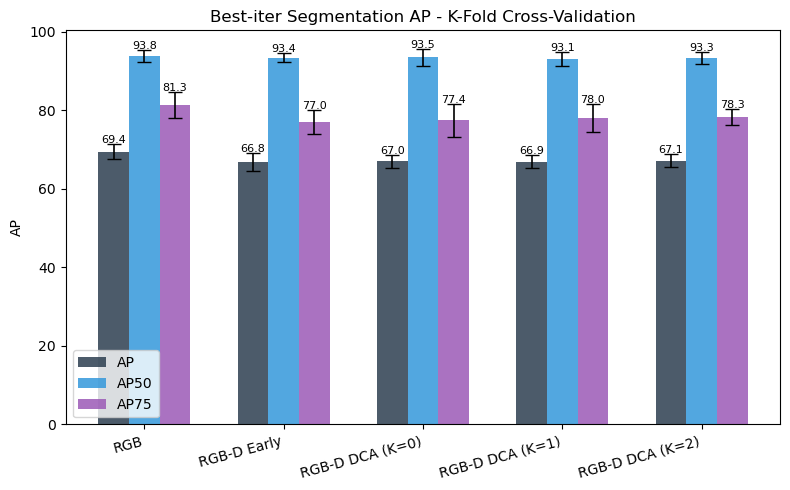

In [38]:
metrics_to_bar = ["segm/AP", "segm/AP50", "segm/AP75"]
variants       = list(cv_summary.index)
x              = np.arange(len(variants))
width          = 0.22
colors_bar     = ["#2c3e50", "#3498db", "#9b59b6"]

fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(variants)), 5))
for i, (metric, color) in enumerate(zip(metrics_to_bar, colors_bar)):
    means = cv_summary[f"{metric}_mean"].values
    stds  = cv_summary[f"{metric}_std"].values
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset, means, width, yerr=stds, capsize=5,
        label=metric.replace("segm/", ""),
        color=color, alpha=0.85, error_kw=dict(elinewidth=1.2)
    )
    for bar, mean_val, std_val in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std_val + 0.3,
            f"{mean_val:.1f}", ha="center", fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(v, v.replace("_swin_tiny", "")) for v in variants], rotation=15, ha="right")
ax.set_ylabel("AP")
ax.set_title("Best-iter Segmentation AP - K-Fold Cross-Validation")
ax.legend()
fig.tight_layout()
plt.show()


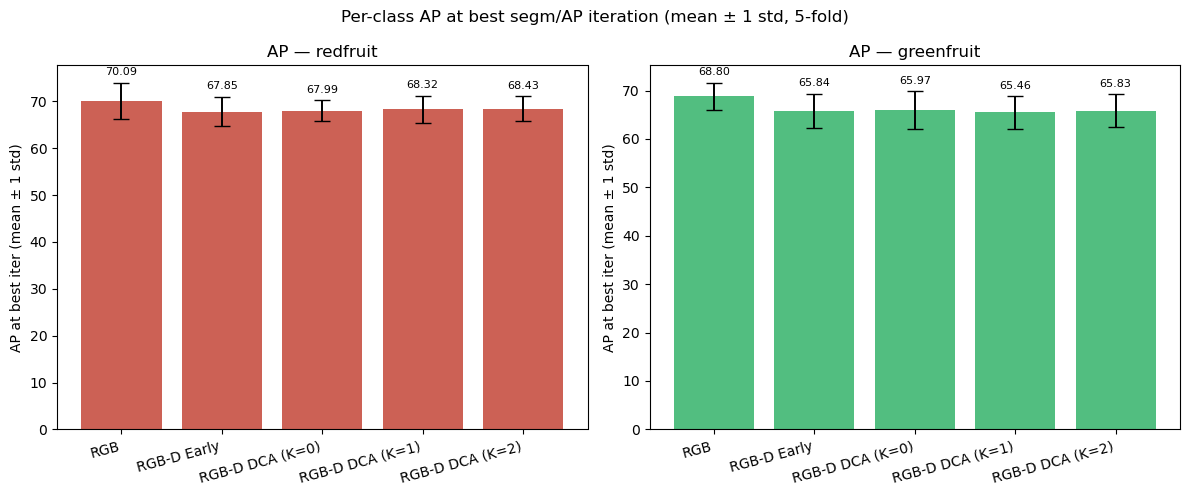

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, metric, title, color in [
    (axes[0], "segm/AP-redfruit",   "AP — redfruit",   "#c0392b"),
    (axes[1], "segm/AP-greenfruit", "AP — greenfruit", "#27ae60"),
]:
    means = cv_summary[f"{metric}_mean"].values
    stds  = cv_summary[f"{metric}_std"].values
    bars = ax.bar(
        range(len(variants)), means, yerr=stds, capsize=6,
        color=color, alpha=0.8, error_kw=dict(elinewidth=1.4)
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("AP at best iter (mean ± 1 std)")
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels([LABELS.get(v, v.replace("_swin_tiny", "")) for v in variants], rotation=15, ha="right")
fig.suptitle("Per-class AP at best segm/AP iteration (mean ± 1 std, 5-fold)")
fig.tight_layout()
plt.show()


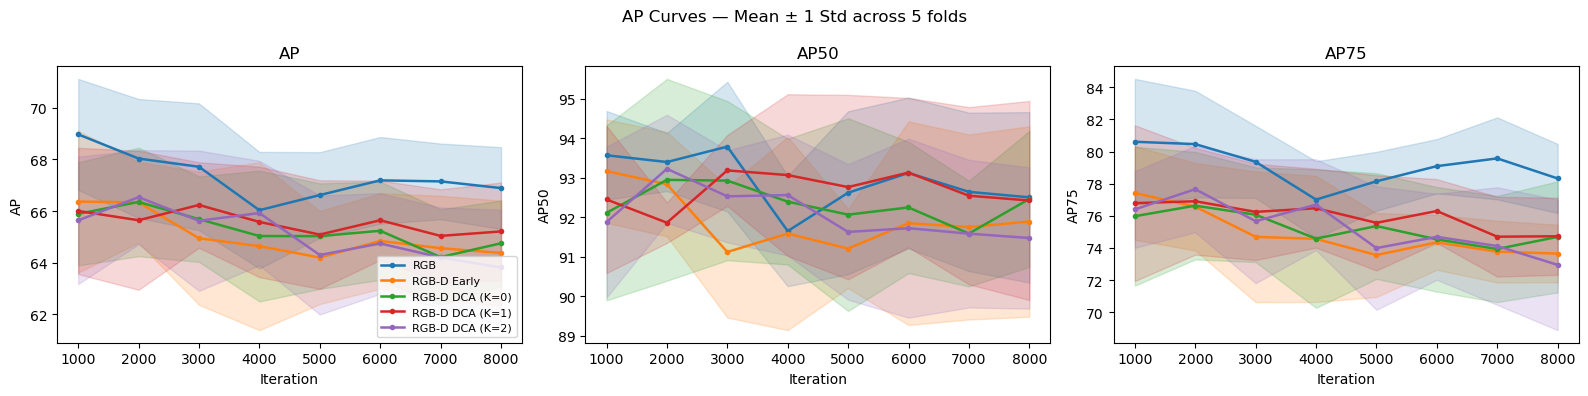

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, metric in zip(axes, ["segm/AP", "segm/AP50", "segm/AP75"]):
    for idx, (variant, fold_dfs) in enumerate(cv_eval.items()):
        color = palette[idx % len(palette)]
        label = LABELS.get(variant, variant.replace("_swin_tiny", ""))

        # Align curves on common iteration checkpoints
        iters_sets = [set(df["iteration"].values) for df in fold_dfs]
        common_iters = sorted(set.intersection(*iters_sets))

        curves = np.array([
            df.set_index("iteration").loc[common_iters, metric].values
            for df in fold_dfs
        ])  # shape: (n_folds, n_checkpoints)

        mean_curve = curves.mean(axis=0)
        std_curve  = curves.std(axis=0, ddof=1)

        ax.plot(common_iters, mean_curve, color=color, marker="o",
                markersize=3, linewidth=1.8, label=label)
        ax.fill_between(
            common_iters,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color, alpha=0.18
        )

    ax.set_title(metric.replace("segm/", ""))
    ax.set_xlabel("Iteration")
    ax.set_ylabel(metric.replace("segm/", ""))

axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("AP Curves — Mean ± 1 Std across 5 folds", fontsize=12)
fig.tight_layout()
plt.show()


## 5.5 Paired statistical comparison

The rubric explicitly rewards a measure of significance. Because all five folds use the
**same seed-42 partition** across every configuration, the per-fold `RGB − variant` differences
are *paired* — the correct setup for a **paired t-test** / **Wilcoxon signed-rank test**. The
cell below reports, for each fusion variant, the mean per-fold AP gap, how many of the five
folds RGB wins, and both p-values. (n = 5, so the smallest possible Wilcoxon p is 0.0625;
report p-values as indicative, leaning on the consistent fold-win count and mean gap.)

In [41]:
# --- 5.5 Paired statistical comparison (RGB baseline vs each fusion variant) ---
# Folds share one seed-42 partition across variants, so per-fold differences are PAIRED.
# We report mean ΔAP, fold-win count, and paired t-test + Wilcoxon signed-rank p-values.
# NOTE: with n=5 the smallest attainable Wilcoxon p is 0.0625 -> treat p as indicative.
from scipy.stats import ttest_rel, wilcoxon

BASELINE = "RGB"


def _fold_index(name: str) -> int:
    m = re.search(r"_fold(\d+)of\d+", name)
    return int(m.group(1)) if m else -1


# Per-fold AP matrix aligned by fold index (rows=fold, cols=display variant name).
ap_by_variant = {}
for variant, best_df in cv_best.items():
    s = best_df["segm/AP"].copy()
    s.index = [_fold_index(i) for i in s.index]
    ap_by_variant[LABELS.get(variant, variant)] = s.sort_index()
ap_mat = pd.DataFrame(ap_by_variant)

assert BASELINE in ap_mat.columns, f"{BASELINE!r} not among {list(ap_mat.columns)}"

stat_rows = []
for col in [c for c in ap_mat.columns if c != BASELINE]:
    paired = ap_mat[[BASELINE, col]].dropna()
    diff = paired[BASELINE] - paired[col]          # positive => RGB better
    n = len(diff)
    _, t_p = ttest_rel(paired[BASELINE], paired[col])
    try:
        _, w_p = wilcoxon(paired[BASELINE], paired[col])
    except ValueError:                              # all-zero diffs
        w_p = np.nan
    stat_rows.append({
        "Comparison": f"{BASELINE} vs {col}",
        "mean ΔAP": diff.mean(),
        "RGB wins": f"{int((diff > 0).sum())}/{n}",
        "paired-t p": t_p,
        "Wilcoxon p": w_p,
    })

stats_df = pd.DataFrame(stat_rows).set_index("Comparison")
print(stats_df.to_string(
    formatters={"mean ΔAP": "{:+.2f}".format,
                "paired-t p": "{:.3f}".format,
                "Wilcoxon p": "{:.3f}".format}))
stats_df


                       mean ΔAP RGB wins paired-t p Wilcoxon p
Comparison                                                    
RGB vs RGB-D Early        +2.60      5/5      0.015      0.062
RGB vs RGB-D DCA (K=0)    +2.46      5/5      0.030      0.062
RGB vs RGB-D DCA (K=1)    +2.55      5/5      0.008      0.062
RGB vs RGB-D DCA (K=2)    +2.31      5/5      0.036      0.062


,mean ΔAP,RGB wins,paired-t p,Wilcoxon p
Comparison,,,,
RGB vs RGB-D Early,2.596787,5/5,0.015316,0.0625
RGB vs RGB-D DCA (K=0),2.460086,5/5,0.030085,0.0625
RGB vs RGB-D DCA (K=1),2.554506,5/5,0.008392,0.0625
RGB vs RGB-D DCA (K=2),2.311826,5/5,0.036337,0.0625


### Figure — paired per-fold AP advantage

A paired-difference view that replaces the redundant grouped/per-class bar charts. Each blue
point is one fold's `ΔAP = RGB − variant`; the red bar is the mean. Points above the dashed
zero line are folds where RGB beats the fusion variant — if all five sit above zero, the
baseline wins *consistently*, a stronger claim than overlapping error bars.

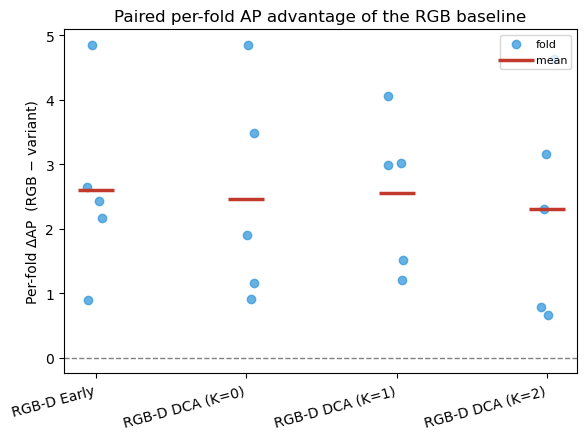

In [42]:
# --- Paired per-fold AP advantage (figure for 5.5) ---
# Because folds are paired (shared seed-42 partition), the honest picture is the
# per-fold gap RGB - variant. Points above the dashed zero line are folds where the
# RGB baseline beats that fusion variant; the red bar marks the mean gap.
BASELINE = "RGB"

# Per-fold AP matrix, aligned by fold index, columns relabelled to display names.
ap_by_variant = {}
for variant, best_df in cv_best.items():
    s = best_df["segm/AP"].copy()
    s.index = [_fold_index(i) for i in s.index]
    ap_by_variant[LABELS.get(variant, variant)] = s.sort_index()
ap_mat = pd.DataFrame(ap_by_variant)

assert BASELINE in ap_mat.columns, f"{BASELINE!r} not among {list(ap_mat.columns)}"
comp_cols = [c for c in ap_mat.columns if c != BASELINE]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(comp_cols)), 4.5))
for i, col in enumerate(comp_cols):
    diff = (ap_mat[BASELINE] - ap_mat[col]).dropna()
    xs = i + rng.uniform(-0.06, 0.06, len(diff))
    ax.scatter(xs, diff.values, color="#3498db", alpha=0.75, zorder=3, label="fold" if i == 0 else None)
    ax.scatter([i], [diff.mean()], color="#c0392b", marker="_", s=700, linewidth=2.5,
               zorder=4, label="mean" if i == 0 else None)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_xticks(range(len(comp_cols)))
ax.set_xticklabels(comp_cols, rotation=15, ha="right")
ax.set_ylabel(f"Per-fold ΔAP  ({BASELINE} − variant)")
ax.set_title(f"Paired per-fold AP advantage of the {BASELINE} baseline")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## 5.6 Held-out 40-image set (independent check)

Re-evaluates the **same checkpoints** behind Table 5.1 — selected on in-fold validation — on
the common 40-image held-out set that was excluded from the cross-validation entirely. If the
ranking here agrees with the CV table, the result is not an artefact of the fold partition.
Produces a compact `mean ± std` table plus a LaTeX export (`tab:heldout_results`).

In [43]:
# --- 5.6 Held-out 40-image set (independent check) ---
# Re-evaluate the SAME checkpoints used in Table 5.1 on the common held-out set
# (rob2pheno_val), which was excluded from the cross-validation entirely.
# Checkpoint selection stays on in-fold validation (cv_best) to avoid selecting on
# the held-out set; we only *read off* held-out metrics at that iteration.
HELDOUT_DATASET = "rob2pheno_val"


def _fold_index(name: str) -> int:
    m = re.search(r"_fold(\d+)of\d+", name)
    return int(m.group(1)) if m else -1


heldout_rows = []
for variant, fold_dirs in fold_groups.items():
    sel_iters = cv_best[variant]["iteration"].astype(int)  # index = fold dirname
    metric_vals: dict[str, list[float]] = {m: [] for m in METRIC_COLS_CV}
    for dirname in sorted(fold_dirs):
        run_path = OUTPUT_DIR / dirname
        if dirname not in sel_iters.index or not (run_path / "metrics.json").exists():
            continue
        _, eval_df = load_metrics(run_path, eval_dataset=HELDOUT_DATASET)
        if eval_df.empty or "segm/AP" not in eval_df.columns:
            print(f"  WARNING: no {HELDOUT_DATASET} segm/AP in {dirname}")
            continue
        eval_df = eval_df.dropna(subset=["segm/AP"]).set_index("iteration")
        it = sel_iters[dirname]
        if it not in eval_df.index:
            print(f"  WARNING: in-fold best iter {it} missing in held-out eval for {dirname}")
            continue
        for m in METRIC_COLS_CV:
            if m in eval_df.columns:
                metric_vals[m].append(float(eval_df.loc[it, m]))
    row = {"variant": variant}
    for m in METRIC_COLS_CV:
        vals = np.array(metric_vals[m], dtype=float)
        if len(vals):
            row[f"{m}_mean"] = vals.mean()
            row[f"{m}_std"] = vals.std(ddof=1)
    heldout_rows.append(row)

heldout_summary = pd.DataFrame(heldout_rows).set_index("variant")

heldout_display = pd.DataFrame(index=heldout_summary.index)
for col in METRIC_COLS_CV:
    mc, sc = f"{col}_mean", f"{col}_std"
    if mc in heldout_summary.columns:
        heldout_display[METRIC_LABELS.get(col, col)] = heldout_summary.apply(
            lambda r, m=mc, s=sc: f"{r[m]:.2f} ± {r[s]:.2f}", axis=1
        )
heldout_display.index = [LABELS.get(v, v) for v in heldout_display.index]
heldout_display.index.name = "Variant"

# LaTeX export (mirrors the cv table cell)
heldout_latex = heldout_display.map(lambda s: s.replace("±", r"$\pm$")).to_latex(
    escape=False,
    column_format="l" + "c" * heldout_display.shape[1],
    caption="Held-out 40-image set: segmentation AP at the in-fold-selected checkpoint "
            "(mean $\\pm$ 1 std across the 5 folds' models).",
    label="tab:heldout_results",
    position="ht",
)
print(heldout_latex)
heldout_display


\begin{table}[ht]
\caption{Held-out 40-image set: segmentation AP at the in-fold-selected checkpoint (mean $\pm$ 1 std across the 5 folds' models).}
\label{tab:heldout_results}
\begin{tabular}{lccccc}
\toprule
 & AP & AP50 & AP75 & AP (red) & AP (green) \\
Variant &  &  &  &  &  \\
\midrule
RGB & 66.06 $\pm$ 1.96 & 92.33 $\pm$ 1.69 & 76.56 $\pm$ 2.17 & 67.74 $\pm$ 2.13 & 64.37 $\pm$ 1.86 \\
RGB-D Early & 64.58 $\pm$ 1.49 & 91.60 $\pm$ 1.13 & 73.90 $\pm$ 1.90 & 66.91 $\pm$ 2.24 & 62.24 $\pm$ 0.84 \\
RGB-D DCA (K=0) & 63.86 $\pm$ 1.43 & 91.27 $\pm$ 1.74 & 73.80 $\pm$ 1.76 & 65.75 $\pm$ 1.82 & 61.97 $\pm$ 1.16 \\
RGB-D DCA (K=1) & 63.82 $\pm$ 1.00 & 91.55 $\pm$ 0.15 & 72.51 $\pm$ 1.65 & 65.10 $\pm$ 1.12 & 62.54 $\pm$ 1.34 \\
RGB-D DCA (K=2) & 63.32 $\pm$ 1.02 & 90.57 $\pm$ 1.20 & 72.60 $\pm$ 2.40 & 65.15 $\pm$ 1.50 & 61.50 $\pm$ 1.08 \\
\bottomrule
\end{tabular}
\end{table}



,AP,AP50,AP75,AP (red),AP (green)
Variant,,,,,
RGB,66.06 ± 1.96,92.33 ± 1.69,76.56 ± 2.17,67.74 ± 2.13,64.37 ± 1.86
RGB-D Early,64.58 ± 1.49,91.60 ± 1.13,73.90 ± 1.90,66.91 ± 2.24,62.24 ± 0.84
RGB-D DCA (K=0),63.86 ± 1.43,91.27 ± 1.74,73.80 ± 1.76,65.75 ± 1.82,61.97 ± 1.16
RGB-D DCA (K=1),63.82 ± 1.00,91.55 ± 0.15,72.51 ± 1.65,65.10 ± 1.12,62.54 ± 1.34
RGB-D DCA (K=2),63.32 ± 1.02,90.57 ± 1.20,72.60 ± 2.40,65.15 ± 1.50,61.50 ± 1.08
